## 02 - EDA & Vendor Performance Analysis

In [1]:
import pandas as pd
from pathlib import Path

PROCESSED_DATA_PATH = (
    Path("..") / "data" / "processed_data" / "scms_clean.pkl"
)

df = pd.read_pickle(PROCESSED_DATA_PATH)


print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10324, 30)


,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,...,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),delay_days,is_delayed,cost_per_kg,value_per_item
0,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,2006-06-02,2006-06-02,2-Jun-06,HRDT,HIV test,...,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.0,780.34,0.0,0,False,60.026154,29.00
1,Vietnam,PMO - US,Direct Drop,EXW,Air,2006-11-14,2006-11-14,14-Nov-06,ARV,Pediatric,...,0.03,"Aurobindo Unit III, India",Yes,358.0,4521.50,0.0,0,False,12.629888,6.20
2,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,2006-08-27,2006-08-27,27-Aug-06,HRDT,HIV test,...,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.0,1653.78,0.0,0,False,9.671228,80.00
3,Vietnam,PMO - US,Direct Drop,EXW,Air,2006-09-01,2006-09-01,1-Sep-06,ARV,Adult,...,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.0,16007.06,0.0,0,False,8.629143,3.99
4,Vietnam,PMO - US,Direct Drop,EXW,Air,2006-08-11,2006-08-11,11-Aug-06,ARV,Adult,...,0.05,"Aurobindo Unit III, India",Yes,7590.0,45450.08,0.0,0,False,5.988153,3.20


In [2]:
df[["delay_days", "cost_per_kg"]].describe()


C:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,delay_days,cost_per_kg
count,10324.000000,1.032400e+04
mean,-6.023537,inf
std,27.233640,NaN
min,-372.000000,0.000000e+00
25%,-3.000000,0.000000e+00
50%,0.000000,1.834405e+00
75%,0.000000,9.143931e+00
max,192.000000,inf


In [3]:
# Check missing values in key numeric fields
# NaN is expected here: text like "Freight Included in Commodity Cost" was kept as NaN in 01 
# (see weight_missing / freight_missing flags)

df[["Weight (Kilograms)", "Freight Cost (USD)"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Weight (Kilograms)  10324 non-null  float64
 1   Freight Cost (USD)  10324 non-null  float64
dtypes: float64(2)
memory usage: 161.4 KB


Summary statistics for key performance metrics: helps understand distribution, variability and potential outliers.

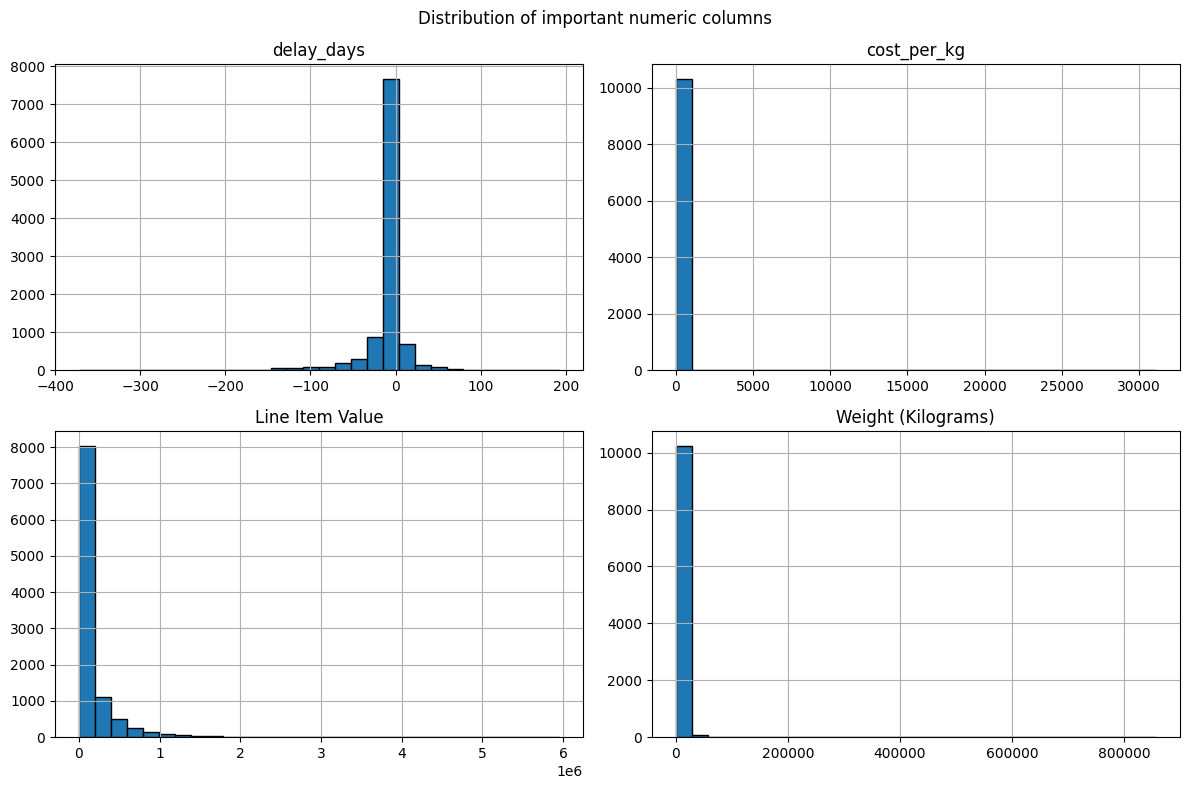

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Distribution plots
plot_columns = [
    "delay_days",
    "cost_per_kg",
    "Line Item Value",
    "Weight (Kilograms)"
]
plot_data = df[plot_columns].replace([np.inf, -np.inf], np.nan).dropna()
plot_data.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.suptitle("Distribution of important numeric columns")
plt.tight_layout()
plt.show()

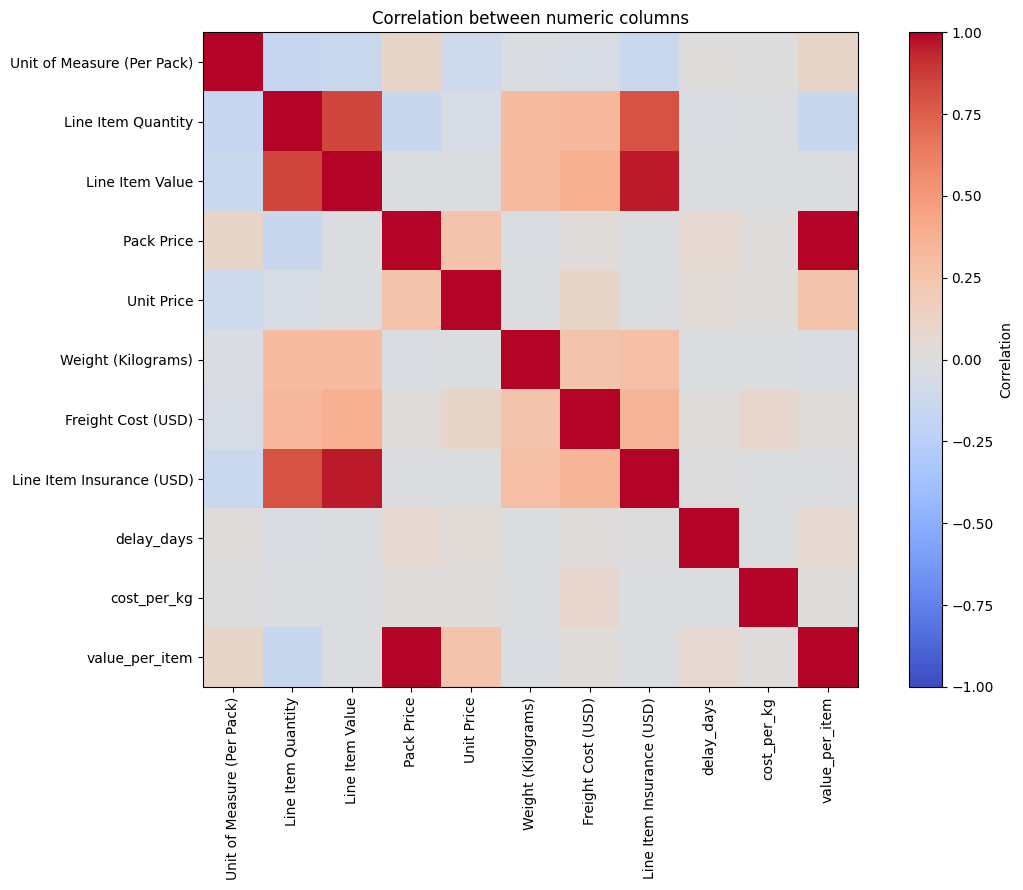

In [5]:
# 2. Correlation heatmap
numeric_data = df.select_dtypes(include="number")
numeric_data = numeric_data.replace([np.inf, -np.inf], np.nan)
correlation = numeric_data.corr()
plt.figure(figsize=(12, 9))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation between numeric columns")
plt.tight_layout()
plt.show()


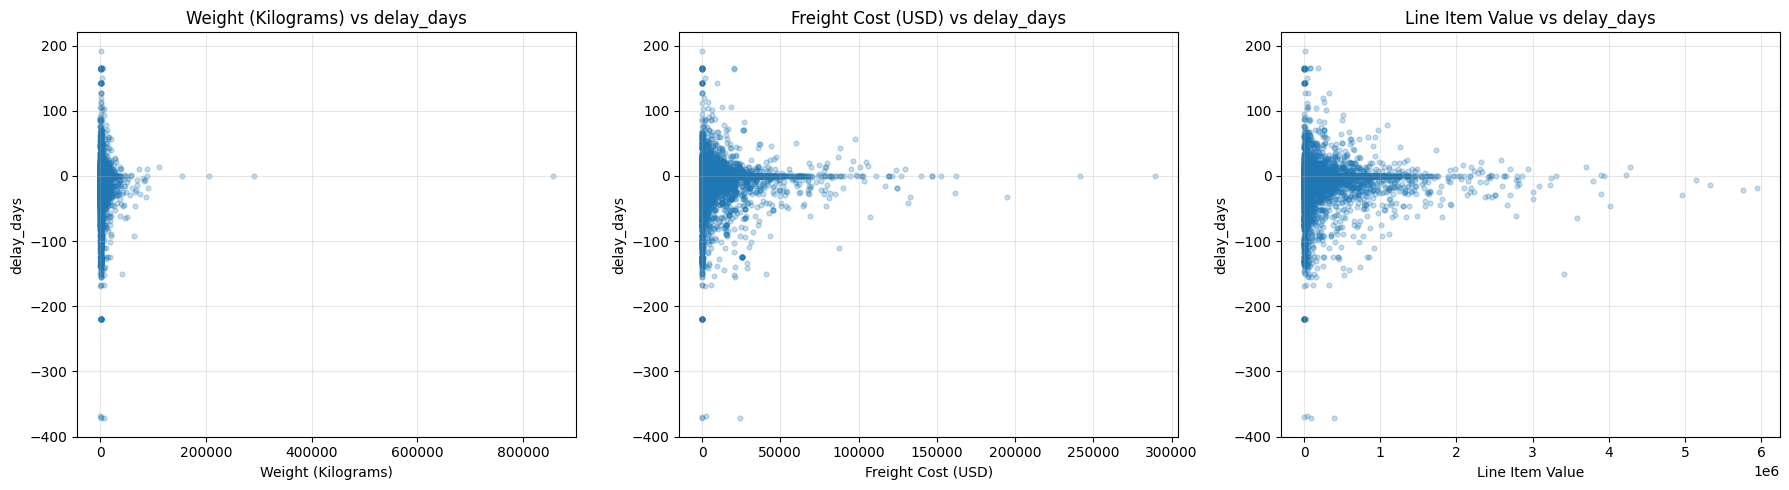

In [6]:
# 3. Scatter plots: straight-line or curved relationships
features = ["Weight (Kilograms)", "Freight Cost (USD)", "Line Item Value"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, feature in zip(axes, features):
    rows = df[[feature, "delay_days"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    axis.scatter(rows[feature], rows["delay_days"], alpha=0.25, s=12)
    axis.set_title(f"{feature} vs delay_days")
    axis.set_xlabel(feature)
    axis.set_ylabel("delay_days")
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

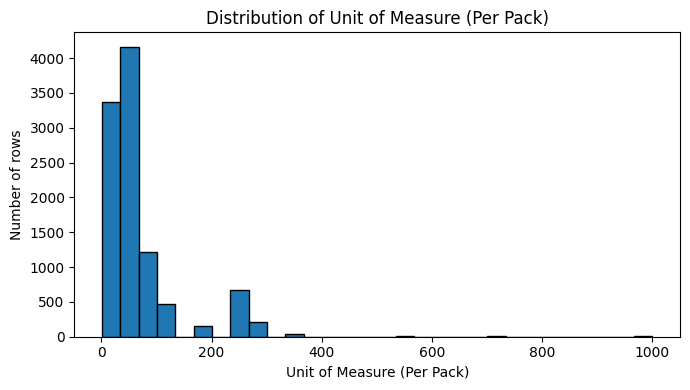

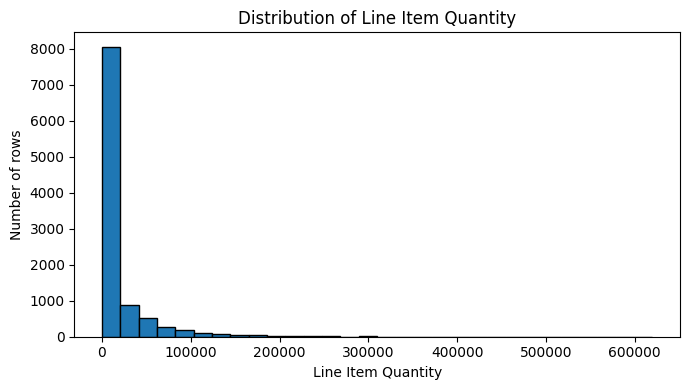

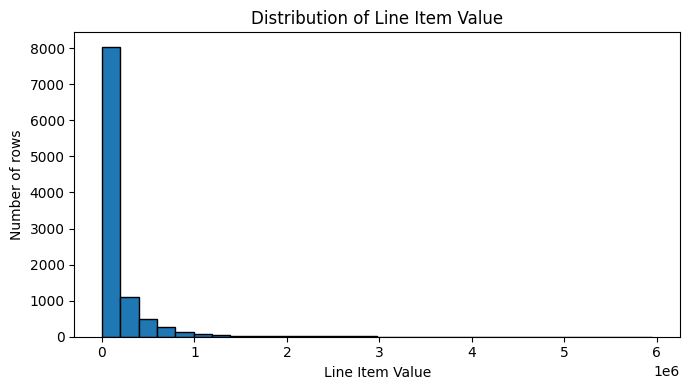

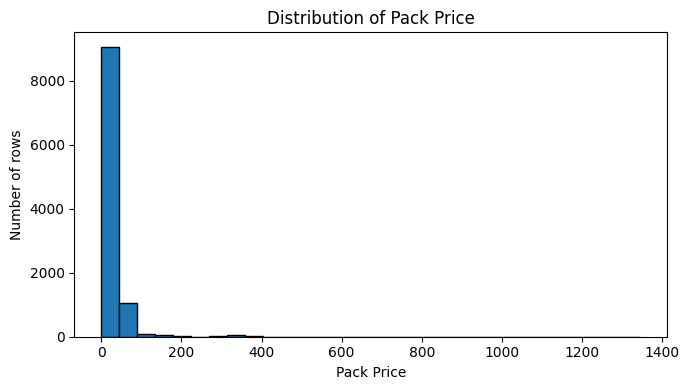

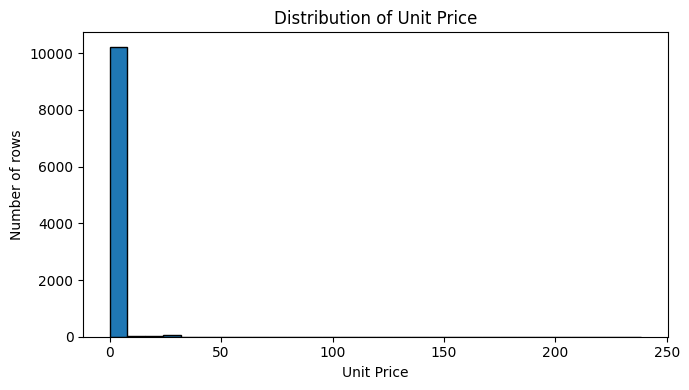

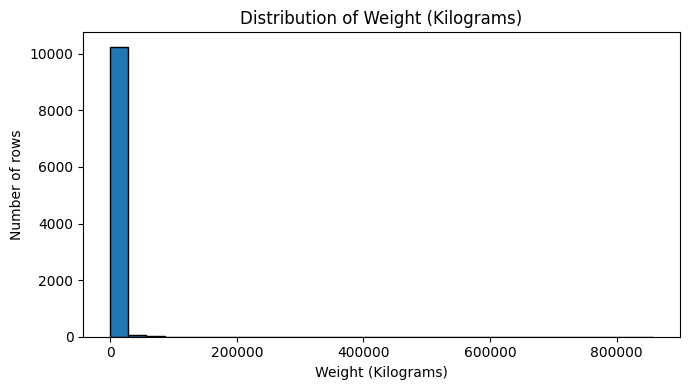

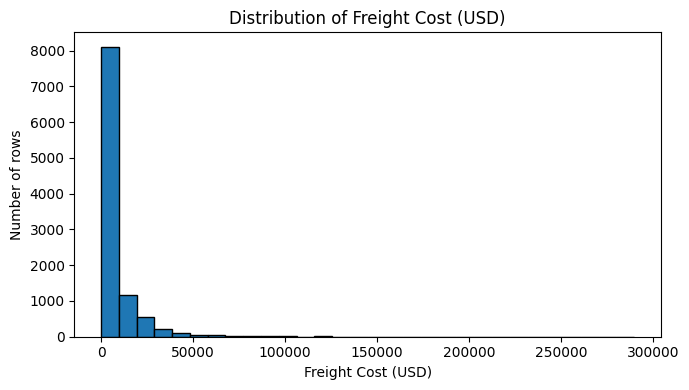

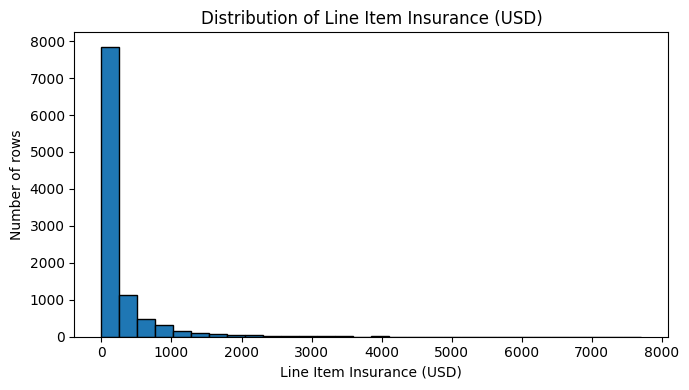

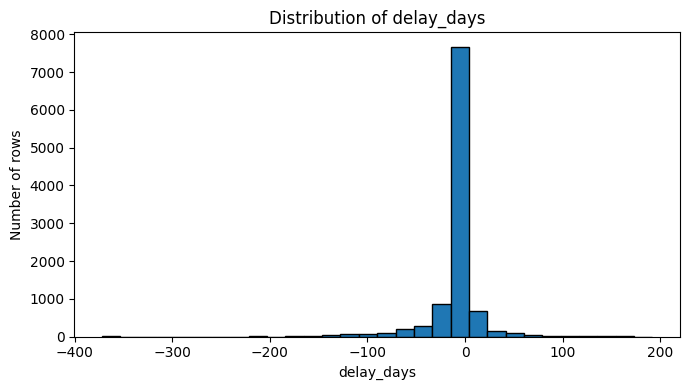

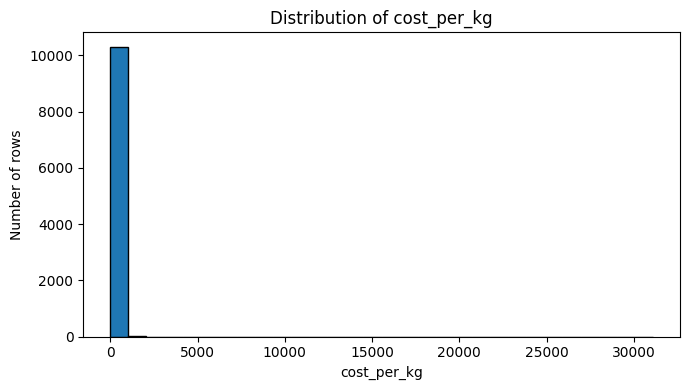

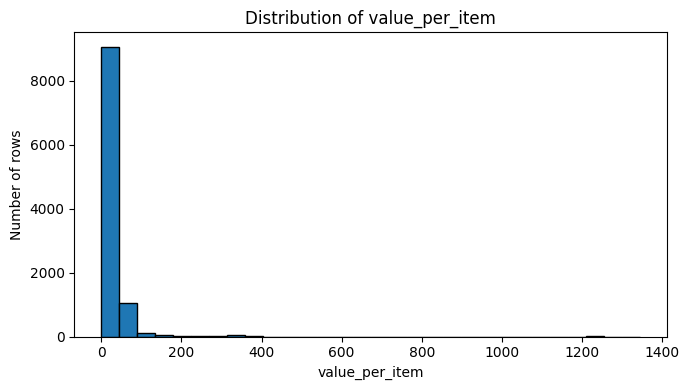

In [7]:
# 4. Distribution plot for every numeric column
all_numeric_columns = df.select_dtypes(include="number").columns
for column in all_numeric_columns:
    values = df[column].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=30, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of rows")
    plt.tight_layout()
    plt.show()


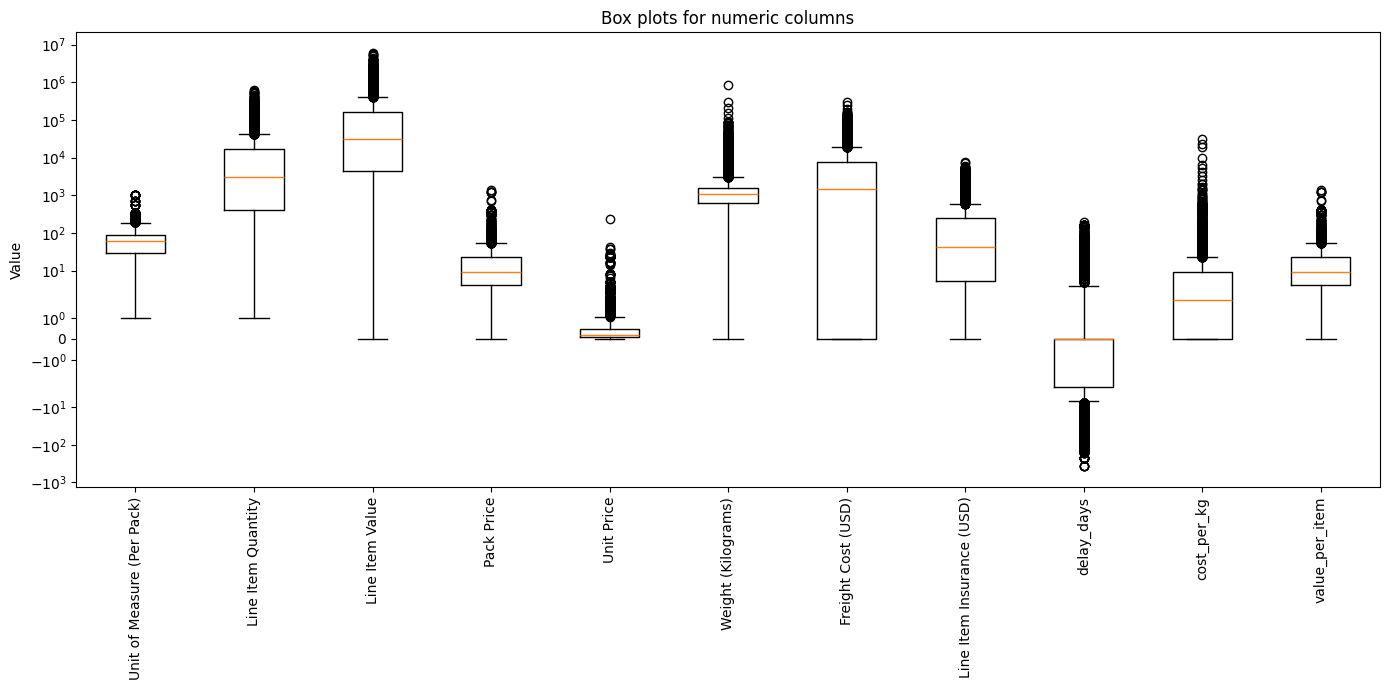

In [8]:
# 5. Box plot for every numeric column
# Points far from the box may be outliers.
plt.figure(figsize=(14, 7))
boxplot_data = [
    df[column].replace([np.inf, -np.inf], np.nan).dropna()
    for column in all_numeric_columns
]
plt.boxplot(boxplot_data, tick_labels=all_numeric_columns, vert=True)
plt.yscale("symlog")   # columns have very different scales
plt.title("Box plots for numeric columns")
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**How to read the scatter plots**

- A straight pattern suggests a linear relationship.
- A curve or groups suggest a non-linear relationship.
- A scattered cloud suggests a weak relationship.

**Summary statistics**

1. **Delay behavior:** both positive and negative delay values -> early and late deliveries.
2. **Variability:** high standard deviation -> inconsistent delivery performance.
3. **Cost efficiency:** wide range in cost_per_kg -> inefficient logistics in some cases.

In [9]:
# vendor performance to identify delay patterns, shipment volume, and cost efficiency

# 1. High Delay Vendors:
# Vendors with high late_delay / pct_delayed are major contributors to inefficiency

# 2. Volume Risk:
# Vendors with high total_shipments + high delay = critical risk

# 3. Cost vs Performance:
# High cost + high delay vendors indicate poor ROI

# Real vendors only: "SCMS from RDC" is a warehouse (Fulfill Via = From RDC), not a manufacturer
d = df[df["Fulfill Via"] == "Direct Drop"].copy()

# Clip extreme delays (likely entry errors) and split late / early at ROW level
d["delay_days"] = d["delay_days"].clip(-60, 60)
d["late_days"] = d["delay_days"].clip(lower=0)
d["early_days"] = (-d["delay_days"]).clip(lower=0)

supplier_df = d.groupby("Vendor").agg(
    avg_delay=("delay_days", "mean"),
    pct_delayed=("is_delayed", "mean"),
    total_shipments=("is_delayed", "size"),   # number of shipments per vendor
    avg_cost=("cost_per_kg", "median"),       # cost per kg is comparable across shipment sizes
    late_delay=("late_days", "mean"),
    early_delivery=("early_days", "mean"),
).reset_index().rename(columns={"Vendor": "supplier_id"})

In [10]:
# Remove unreliable vendor records

# Filter 1: Remove vendors with zero/invalid cost

supplier_df = supplier_df[supplier_df["avg_cost"] > 0]

# Filter 2: Remove low-volume vendors

supplier_df = supplier_df[supplier_df["total_shipments"] > 10]

Late and early days are now calculated per shipment in the vendor table above (so early shipments no longer cancel out late ones).

In [11]:
# Normalize late delay into a score (higher is better)
# 1 = best (no delays)
# 0 = worst (highest delay vendor)

if supplier_df["late_delay"].max() == 0:
    supplier_df["delay_score"] = 1
else:
    supplier_df["delay_score"] = 1 - (
        supplier_df["late_delay"] / supplier_df["late_delay"].max()
    )

In [12]:
# Cap extreme early deliveries (avoid outliers dominating)
early_cap = supplier_df["early_delivery"].quantile(0.95)

if early_cap == 0:
    supplier_df["early_score"] = 0
else:
    supplier_df["early_score"] = (
        supplier_df["early_delivery"] / early_cap
    ).clip(0, 1)

In [13]:
# Combine delay penalty and early reward into final on-time score

supplier_df["on_time_rate"] = (
    0.8 * supplier_df["delay_score"] +
    0.2 * supplier_df["early_score"]     
).clip(0, 1)

**Weighting logic:** delay impacts customer satisfaction more (80%); early delivery is beneficial but less critical (20%).

In [14]:
# Normalize cost (lower cost = better score)
# 1 = lowest cost vendor (best)
# 0 = highest cost vendor (worst)


supplier_df["cost_score"] = (
    supplier_df["avg_cost"].max() - supplier_df["avg_cost"]
) / supplier_df["avg_cost"].max()

**Final score** balances reliability (on_time_rate) and cost efficiency (cost_score), to identify high-performing vendors (high score, low delay, low cost) and risky vendors (high delay, high cost).

## Final Vendor Ranking & Performance Index

In [15]:
# Volume score -> represents operational scale & reliability
# Log scale so one huge vendor does not squash everyone else
import numpy as np

supplier_df["volume_score"] = (
    np.log1p(supplier_df["total_shipments"]) / np.log1p(supplier_df["total_shipments"].max())
)

In [16]:
# Final composite supplier score (Business-weighted model)

supplier_df["supplier_score"] = (
    0.6 * supplier_df["on_time_rate"] + 
    0.25 * supplier_df["cost_score"] + 
    0.15 * supplier_df["volume_score"] 
)

**Weighting strategy**

- Reliability (60%): most critical for customer satisfaction & SLA
- Cost (25%): important but secondary to delivery performance
- Volume (15%): vendor experience & scalability

Higher score -> better overall vendor performance.

*Weights are business assumptions, not fitted values. Only Direct Drop vendors are ranked.*

In [17]:
# Top-performing vendors (Best in reliability + cost + scale)


supplier_df.sort_values(by="supplier_score", ascending=False).head()

,supplier_id,avg_delay,pct_delayed,total_shipments,avg_cost,late_delay,early_delivery,delay_score,early_score,on_time_rate,cost_score,volume_score,supplier_score
28,HETERO LABS LIMITED,-0.209386,0.007220,277,1.651847,0.032491,0.241877,0.992285,0.060594,0.805947,0.932690,0.849232,0.844125
21,"CHEMBIO DIAGNOSTIC SYSTEMS, INC.",-3.724771,0.009174,109,9.234345,0.220183,3.944954,0.947718,0.988279,0.955830,0.623716,0.709323,0.835825
46,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,-0.356467,0.006309,317,3.368823,0.018927,0.375394,0.995506,0.094043,0.815213,0.862726,0.869518,0.835237
18,BRISTOL-MYERS SQUIBB,0.000000,0.000000,67,0.097027,0.000000,0.000000,1.000000,0.000000,0.800000,0.996046,0.636742,0.824523
31,IDA FOUNDATION,-7.058824,0.000000,17,9.026434,0.000000,7.058824,1.000000,1.000000,1.000000,0.632188,0.436169,0.823472


In [18]:
# Lowest-performing vendors (High risk / inefficiency)


supplier_df.sort_values(by="supplier_score").head()

,supplier_id,avg_delay,pct_delayed,total_shipments,avg_cost,late_delay,early_delivery,delay_score,early_score,on_time_rate,cost_score,volume_score,supplier_score
22,CIPLA LIMITED,3.611429,0.131429,175,3.241643,4.211429,0.600000,0.000000,0.150310,0.030062,0.867908,0.780248,0.352052
13,Aurobindo Pharma Limited,3.531437,0.140719,668,2.776828,4.064371,0.532934,0.034919,0.133509,0.054637,0.886849,0.981751,0.401757
15,BIO-RAD LABORATORIES (FRANCE),2.107143,0.142857,28,15.252890,2.142857,0.035714,0.491180,0.008947,0.394734,0.378470,0.508139,0.407679
12,Abbott GmbH & Co. KG,2.285714,0.047619,21,6.920496,2.285714,0.000000,0.457259,0.000000,0.365807,0.718001,0.466452,0.468952
49,Orasure Technologies Inc.,0.500000,0.017857,56,24.540860,0.500000,0.000000,0.881275,0.000000,0.705020,0.000000,0.610114,0.514529


## Final Business Summary

**Key Findings**
- Significant variation exists in vendor performance across delay, cost, and reliability
- A small group of vendors consistently outperform others
- Some high-cost vendors also exhibit poor delivery performance -> high risk

**Business Impact**
- Poor vendor performance directly contributes to shipment delays
- High-delay vendors increase operational cost and reduce customer satisfaction

**Recommendations**
- Prioritize high-scoring vendors for critical shipments
- Reassess contracts with low-performing vendors
- Monitor vendor performance continuously using this scoring model

**Strategic Value**

This model enables proactive supply chain optimization by balancing speed (delivery performance), cost (efficiency) and reliability (consistency).

In [19]:
import os

vendor_summary = (
    df.groupby("Vendor")
    .agg(
        shipment_count=("Vendor", "size"),
        average_delay=("delay_days", "mean"),
        delay_rate=("is_delayed", "mean"),
        average_freight_cost=("Freight Cost (USD)", "mean")
    )
    .sort_values("delay_rate", ascending=False)
)

vendor_output_path = (
    Path("..") / "data" / "processed_data" / "vendor_scores.pkl"
)

vendor_summary.to_pickle(vendor_output_path)

print(f"Saved vendor analysis to: {vendor_output_path}")

Saved vendor analysis to: ..\data\processed_data\vendor_scores.pkl
